In [1]:
import pandas as pd
import numpy as np
import os
import sys
notebook_dir = os.path.abspath(os.path.dirname(''))
project_root = os.path.dirname(notebook_dir)
sys.path.append(project_root)
import pandas as pd
from src.utils.db_utils import get_connection, execute_query

from src.features import team_level_features
from src.utils.y_variable import build_spread_variable

from sklearn.ensemble import RandomForestRegressor

In [2]:
stats=["net_pass_yards", "turnovers", "total_yards", "first_downs"]

# training_seasons=["2015", "2016", "2017", "2018", "2019","2020","2021", "2022", "2023"]
training_seasons=["2021", "2022", "2023"]

test_seasons=["2024"]

In [3]:
def build_data_set(stats, training_seasons):
    
    feature_names=[]

    for i_feature in stats:
        feature_names.append(f"home team {i_feature}")
        feature_names.append(f"away team {i_feature}")
    feature_names.append("spread")   
    x_features_df=pd.DataFrame(columns=feature_names)
    all_stat_dict={}
    for i_stat in stats:
        stat_list=[]
        for i_season in training_seasons:

            yards_pg, average_stats_pg=team_level_features.generic_team_stats_per_game(i_season, i_stat)
            stat_list.append(average_stats_pg)
            y_out=build_spread_variable(i_season)
            
            keys=y_out.keys()
            weeks=list(keys)
            
            for i_week in weeks:
                for i_game in range(len(y_out[i_week][0])):
                    home_team=y_out[i_week][0][i_game]
                    away_team=y_out[i_week][1][i_game]
                    x_features_df.loc[f"{i_season}_{i_week}_{i_game}",f"home team {i_stat}"]=average_stats_pg.loc[i_week, home_team]
                    x_features_df.loc[f"{i_season}_{i_week}_{i_game}",f"away team {i_stat}"]=average_stats_pg.loc[i_week, away_team]
                    x_features_df.loc[f"{i_season}_{i_week}_{i_game}","spread"]=y_out[i_week][2][i_game]
                    
                    
            
        current_stat_df=pd.concat(stat_list, axis=0)
        all_stat_dict[i_stat]=[current_stat_df]
    return x_features_df
        


In [4]:
x_features_df_training=build_data_set(stats, training_seasons)
x_features_df_test=build_data_set(stats, test_seasons)

Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!
Successfully connected to the database!


In [5]:
x_features_df=x_features_df_training.dropna()

In [6]:
model=RandomForestRegressor()
model=model.fit(X=x_features_df.iloc[:,:-1], y=x_features_df.iloc[:,-1])

In [8]:
model.predict(x_features_df_test.iloc[:,:-1])

array([-6.500e+00,  4.210e+00, -1.694e+01,  6.510e+00,  4.900e+00,
       -1.534e+01, -1.062e+01,  7.830e+00,  2.178e+01, -1.040e+00,
        1.232e+01,  1.425e+01, -1.215e+01,  7.260e+00, -2.310e+00,
        2.442e+01,  3.030e+00, -1.188e+01, -1.226e+01,  3.750e+00,
        1.452e+01,  4.110e+00, -9.150e+00,  3.540e+00,  8.800e-01,
        2.398e+01,  1.432e+01,  7.330e+00, -1.524e+01,  2.250e+00,
        1.551e+01,  1.372e+01,  1.700e+00,  2.780e+00,  4.880e+00,
       -4.460e+00, -1.060e+00, -1.152e+01,  6.530e+00,  3.750e+00,
        1.090e+00,  2.590e+00, -4.920e+00, -1.066e+01, -1.061e+01,
        3.910e+00,  6.340e+00, -7.590e+00, -3.550e+00,  7.600e-01,
       -1.400e-01, -7.740e+00, -6.190e+00,  8.850e+00,  4.530e+00,
        5.990e+00,  2.240e+00, -8.020e+00,  1.372e+01,  4.510e+00,
        6.800e+00,  1.182e+01,  5.340e+00,  2.490e+00,  4.320e+00,
       -4.500e-01, -1.340e+00, -4.580e+00,  2.810e+00,  3.510e+00,
       -1.600e+00,  1.811e+01,  5.150e+00,  3.980e+00, -4.410e

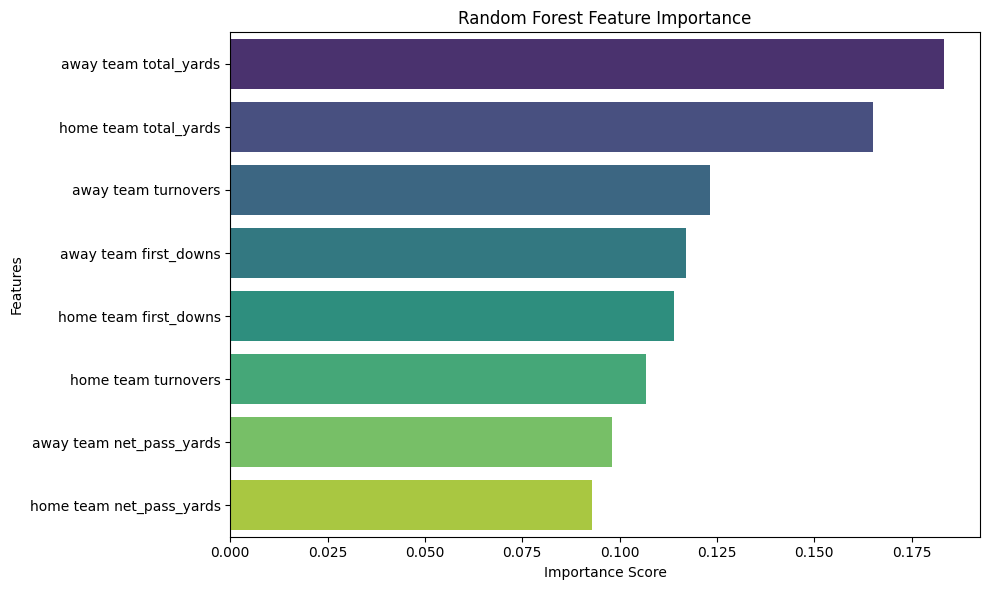

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
feature_importance = pd.DataFrame({
    'feature': x_features_df.iloc[:,:-1].columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)


# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', 
            palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()